# t-Test
    A t-Test is a statistical hypothesis test used to determine whether the sample mean is significantly different from a known population mean or whether the means of two groups are significantly different.

    Unlike the Z-Test, the t-Test is used when the population standard deviation is unknown.

    Instead of using the population standard deviation, the sample standard deviation is used to estimate the variability of the data.

    A t-Test should be used when
        - The population standard deviation is unknown.
        - The sample standard deviation is available.
        - The sample is randomly selected.
        - The observations are independent.
        - The sample comes from an approximately normal population.
        - The Sample Size Can Be Small And large.)

###  t-Test Statistic
    Formula

$$
t=\frac{\bar{x}-\mu}{S/\sqrt{n}}
$$
     
     where

- $\bar{x}$ = Sample Mean
- $\mu$ = Population Mean
- $S$ = Sample Standard Deviation
- $n$ = Sample Size

### Student's t-Distribution
    The Student's t-Distribution is a probability distribution that is similar to the Standard Normal Distribution.

    However,
        it has thicker tails.
                The thicker tails account for the additional uncertainty introduced when the population standard deviation is estimated using the sample standard deviation.

        As the sample size increases,
                the t-Distribution becomes almost identical to the Standard Normal Distribution.

### Degrees of Freedom
    The t-Distribution depends on the Degrees of Freedom.

    The formula is
$$
df=n-1
$$

    where
- $df$ = Degrees of Freedom
- $n$ = Sample Size


### The t-Test assumes
    - The observations are randomly selected.
    - The observations are independent.
    - The population is approximately normally distributed.
    - The population standard deviation is unknown.

### Types Of t-Test

### 1.One-Sample t-Test
    A One-Sample t-Test is used to determine whether the sample mean is significantly different from a known population mean when the population standard deviation is unknown.

    Instead of using the population standard deviation, the sample standard deviation is used to estimate the variability.

    - Ho States No Significant difference between Sample Mean And Popolation Mean.
    - Ha States There Is Significant difference between Sample Mean And Popolation Mean

    Function
        stats.ttest_1sam(sample_data,Population_mean)

### Business Problem
    A company claims that the average monthly salary of its employees is ₹60,000.

    The HR department selects a random sample of 50 employees.

    The sample mean salary is obtained from the sample.

    The population standard deviation is unknown.

    The analyst wants to determine whether the company's claim is correct at the 5% significance level.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as sts

In [2]:
np.random.seed(42)

Employees = pd.DataFrame({

    "Employee_ID": range(1,51),

    "Monthly_Salary": np.random.normal(

        loc=60000,

        scale=7000,

        size=50

    )

})

Employees.head()

,Employee_ID,Monthly_Salary
0,1,63476.999071
1,2,59032.149892
2,3,64533.819767
3,4,70661.208995
4,5,58360.926377


### The Shapiro-Wilk Test 
    The Shapiro-Wilk Test is a statistical test used to determine whether a dataset follows a Normal Distribution.

    Null Hypothesis

$$
H_0:\text{The data follows a Normal Distribution}
$$

    Alternative Hypothesis

$$
H_1:\text{The data does not follow a Normal Distribution}
$$

    A p-value greater than 0.05 indicates that the data is normaly Distributed.

    A p-value less than or equal to 0.05 indicates that the data significantly not  form a Normal Distribution.

In [44]:
from scipy.stats import shapiro

statistic, p_value = shapiro(Employees["Monthly_Salary"])

print(f"Shapiro Statistic : {statistic:.4f}")

print(f"p-value : {p_value:.4f}")

if p_value > 0.05:

    print("Data is Normally Distributed")

else:

    print("Data is NOT Normally Distributed")

Shapiro Statistic : 0.9827
p-value : 0.6722
Data is Normally Distributed


### State the Hypotheses
    Null Hypothesis
$$
H_0:\mu=60000
$$
    
    Alternative Hypothesis

$$
H_1:\mu\neq60000
$$
    
    This is a Two-Tailed t-Test.

### Sample Information
    Population Mean

$$
\mu=60000
$$

    Sample Mean

$$
\bar{x}=Sample\ Mean
$$

    Sample Standard Deviation

$$
s=Sample\ Standard\ Deviation
$$

    Sample Size

$$
n=50
$$

    Significance Level

$$
\alpha=0.05
$$

In [5]:
population_mean = 60000

alpha = 0.05

sample_mean = Employees["Monthly_Salary"].mean()

sample_std = Employees["Monthly_Salary"].std()

sample_size = len(Employees)

print(f"Population Mean : {population_mean:.2f}")

print(f"Sample Mean : {sample_mean:.2f}")

print(f"Sample Standard Deviation : {sample_std:.2f}")

print(f"Sample Size : {sample_size}")

Population Mean : 60000.00
Sample Mean : 58421.68
Sample Standard Deviation : 6535.68
Sample Size : 50


In [6]:
# Degrees Of Freedom (df)

df = sample_size - 1

print(f"Degrees of Freedom : {df}")

Degrees of Freedom : 49


In [7]:
# Standard Error

SE = sample_std / np.sqrt(sample_size)

print(f"Standard Error : {SE:.2f}")

Standard Error : 924.28


### Calculate the t-Test Statistic

    Formula

$$
t=\frac{\bar{x}-\mu}{s/\sqrt{n}}
$$

In [10]:
t_statistic = ( sample_mean - population_mean ) / SE

print(f"t_Statistic : {t_statistic:.2f}")

t_Statistic : -1.71


### Calculate the p-value
    Python provides a built-in function for performing a One-Sample t-Test.

    This Finction Returns The t_statistics And p_value.
    

In [11]:
from scipy.stats import ttest_1samp

t_statistic, p_value = ttest_1samp(

    Employees["Monthly_Salary"],

    population_mean

)

print(f"t Statistic : {t_statistic:.2f}")

print(f"p-value : {p_value:.4f}")

t Statistic : -1.71
p-value : 0.0940


### Make the Statistical Decision
    Decision Rule
                                                        If
$$
p\le\alpha
$$
        
                                                                Reject the Null Hypothesis.
        
                                                        Otherwise
        
$$
p>\alpha
$$

                                                                Fail to Reject the Null Hypothesis.

In [12]:
if p_value <= alpha:

    print("Reject the Null Hypothesis")

else:

    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


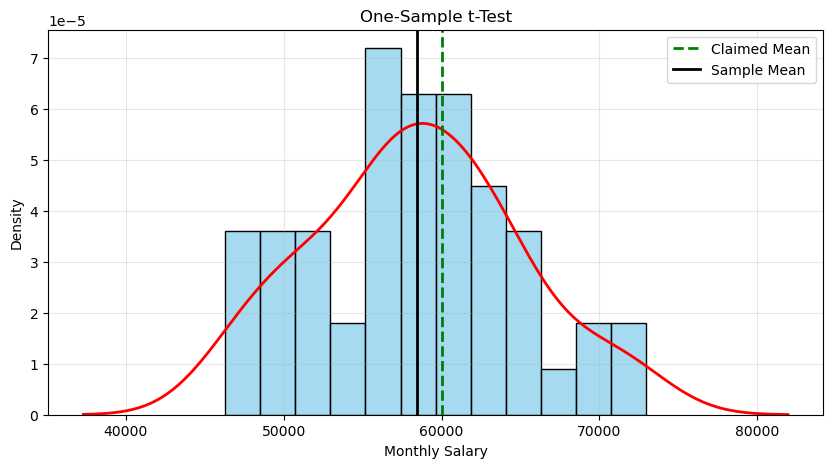

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(

    Employees["Monthly_Salary"],

    bins=12,

    stat="density",

    color="skyblue",

    edgecolor="black"

)

sns.kdeplot(

    Employees["Monthly_Salary"],

    linewidth=2,

    color="red"

)

plt.axvline( population_mean,color="green",linestyle="--",linewidth=2,label="Claimed Mean" )

plt.axvline(

    sample_mean,

    color="black",

    linewidth=2,

    label="Sample Mean"

)

plt.title("One-Sample t-Test")

plt.xlabel("Monthly Salary")

plt.ylabel("Density")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Decision Making in a t-Test
    After calculating the t Statistic,
        the final statistical decision can be made using one of two methods.

        1. Critical Value Approach

        2. p-value Approach

.

### Method 1: Critical Value Approach
    The Critical Value Approach compares the calculated t Statistic with the Critical t Value.

    If the calculated t Statistic falls inside the Rejection Region,

        Reject the Null Hypothesis.

    Otherwise,

        Fail to Reject the Null Hypothesis.

### Critical Value
    Unlike the Z-Test,
        the Critical Value in a t-Test depends on
            - Significance Level
            - Degrees of Freedom

    For our example

$$
df=49
$$

    and

$$
\alpha=0.05
$$

    The Critical Values are approximately

$$
\pm2.01
$$

In [18]:
from scipy.stats import t
alpha=0.05
df=49
critical_value = t.ppf( 1 - alpha/2,df)  # 1-0.05/2 Beacause Two Tailed So Divide by 2 (alpha=0.05)

print(f"Critical Value : ±{critical_value:.2f}")

Critical Value : ±2.01


### Example
                Suppose

                    Calculated t Statistic

$$
t=1.45
$$

                    Critical Values

$$
-2.01
\quad\text{and}\quad
+2.01
$$

                    Since

$$
-2.01<1.45<2.01
$$

                    the calculated t Statistic lies inside the Acceptance Region.

                    Therefore,
                        Fail to Reject the Null Hypothesis.

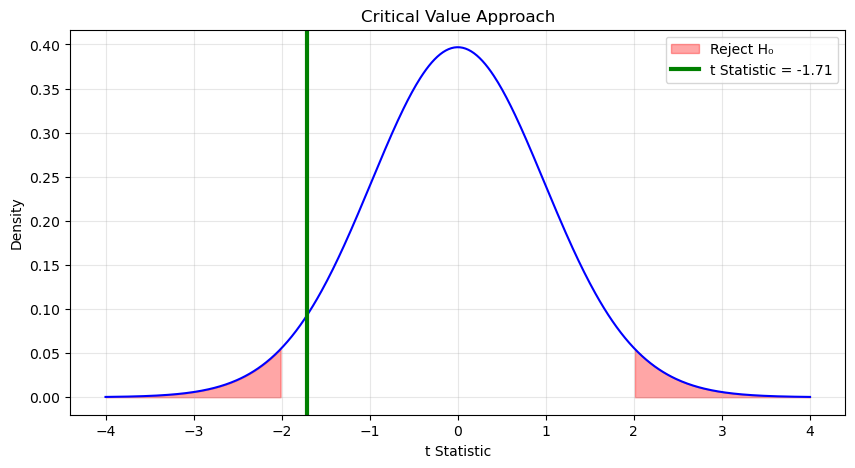

In [19]:
x = np.linspace(-4,4,500)

y = t.pdf(x,df)

plt.figure(figsize=(10,5))

plt.plot(

    x,

    y,

    color="blue"

)

plt.fill_between( x, y, where=(x<=-critical_value), color="red", alpha=0.35, label="Reject H₀")

plt.fill_between( x, y, where=(x>=critical_value), color="red",alpha=0.35 )

plt.axvline( t_statistic, color="green",linewidth=3,label=f"t Statistic = {t_statistic:.2f}" )

plt.title("Critical Value Approach")

plt.xlabel("t Statistic")

plt.ylabel("Density")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### We Observe That
    The calculated t Statistic does not fall inside either rejection region.

    Therefore,
        there is insufficient evidence to reject the Null Hypothesis.

### Method 2: p-value Approach
    The p-value Approach compares the calculated p-value with the Significance Level.
    
   

In [38]:
from scipy.stats import ttest_1samp

p_valuefind =ttest_1samp( Employees["Monthly_Salary"],population_mean)

In [42]:
print("Stat_Value && p-value && DF :",p_valuefind)

print(f"Alpha : {alpha}")

Stat_Value && p-value && DF : TtestResult(statistic=np.float64(-1.7076090630948204), pvalue=np.float64(0.0940383741492245), df=np.int64(49))
Alpha : 0.05


In [43]:
# 0.0940383741492245 > 0.05
p_value=0.0940383741492245
if p_value <= alpha:

    print("Reject the Null Hypothesis")

else:

    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


## 2. Independent Two-Sample t-Test
    An Independent Two-Sample t-Test is used to compare the means of two independent groups.

     - Ho States No Significant difference between Sample Mean And Popolation Mean.
     - Ha States There Is Significant difference between Sample Mean And Popolation Mean
     - Two Samples have the same variance(Perfect Assumption).
     
    Business Example
        An HR analyst wants to compare the average monthly salary of employees working in the Sales department and the IT department.

        The analyst wants to determine whether the average salaries of the two departments are significantly different.

## Levene's Test
    Levene's Test is used to determine whether two or more groups have equal variances.

    Before performing an Independent Two-Sample t-Test, we should check whether the variances of the groups are equal.

    The result helps us decide whether to use
        - Student's t-Test (`equal_var=True`)
        - Welch's t-Test (`equal_var=False`)

### Hypotheses In Levene's
Null Hypothesis ( {p > 0.05} Then Sample_variance1 = Sample_variance2)
    
$$
H_0:\sigma_1^2=\sigma_2^2
$$

            The variances of the groups are equal.

Alternative Hypothesis ( { p <= 0.05} Then Sample_variance1 $\neq$ Sample_variance2 )

$$
H_1:\sigma_1^2\neq\sigma_2^2
$$

            The variances of the groups are not equal.

In [50]:
from scipy.stats import levene

statistic, p_value = levene(Sales,IT)

print(f"Levene Statistic : {statistic:.4f}")

print(f"p-value : {p_value:.4f}")

Levene Statistic : 2.0687
p-value : 0.1557


### Welch's t-Test
        Welch's t-Test is a variation of the Independent Two-Sample t-Test.

        It is used to compare the means of two independent groups when the group variances are not equal.

# Formula

    The test statistic is

$$
t=
\frac{\bar{x}_1-\bar{x}_2}
{\sqrt{\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}}}
$$

    where

- $\bar{x}_1$ = Mean of Group 1
- $\bar{x}_2$ = Mean of Group 2
- $s_1$ = Standard Deviation of Group 1
- $s_2$ = Standard Deviation of Group 2
- $n_1$ = Sample Size of Group 1
- $n_2$ = Sample Size of Group 2

### Student's t-Test vs Welch's t-Test

| Student's t-Test | Welch's t-Test |
|------------------|----------------|
| Assumes equal variances | Does not assume equal variances |
| Uses `equal_var=True` | Uses `equal_var=False` |
| Recommended when Levene's Test p > 0.05 | Recommended when Levene's Test p ≤ 0.05 |
| Less robust if variances differ | More robust when variances differ |

In [51]:
if p_value > 0.05:

    print("Variances are Equal")

    print("Use Student's t-Test (equal_var=True)")

else:

    print("Variances are NOT Equal")

    print("Use Welch's t-Test (equal_var=False)")

Variances are Equal
Use Student's t-Test (equal_var=True)


In [45]:
np.random.seed(42)

Sales = np.random.normal( loc=55000, scale=5000,size=30 )

IT = np.random.normal( loc=60000, scale=6000, size=30 )

Departments = pd.DataFrame({
                       "Sales": Sales,

                       "IT": IT
                    })

Departments.head()

,Sales,IT
0,57483.570765,56389.760327
1,54308.678494,71113.669107
2,58238.442691,59919.016652
3,62615.149282,53653.734426
4,53829.233126,64935.269473


### 
    Null Hypothesis

$$
H_0:\mu_1=\mu_2
$$

    Alternative Hypothesis

$$
H_1:\mu_1\neq\mu_2
$$

In [46]:
print("Sales Mean :", Sales.mean())

print("IT Mean :", IT.mean())

Sales Mean : 54059.265520744804
IT Mean : 59273.02517826033


In [49]:
from scipy.stats import ttest_ind

# This assumes both groups have equal variances (Student's t-test).
t_statistic, p_value = ttest_ind( Sales,IT,equal_var=True)

print(f"t Statistic : {t_statistic:.2f}")

print(f"p-value : {p_value:.4f}")

t Statistic : -3.98
p-value : 0.0002


In [48]:
alpha = 0.05

if p_value <= alpha:

    print("Reject the Null Hypothesis")

else:

    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


## Paired t-Test (Dependent Two-Sample t-Test)
    A Paired t-Test is used to compare the means of two related measurements.
        Unlike the Independent Two-Sample t-Test,

    the observations in both groups are dependent because they are collected from the same subjects at two different times or under two different conditions.

    The Paired t-Test measures whether the average difference between the paired observations is statistically significant.

    

## Assumptions of the Paired t-Test

### 1. Paired Observations
    The observations must come from the same subjects or matched pairs.

    Examples
    - Before and After Training
    - Before and After Treatment

---

### 2. Dependent Samples
    The two samples must be related.
        Each observation in the first sample must have one corresponding observation in the second sample.

---

### 3. Continuous Data
    The dependent variable should be measured on a continuous scale.

    Examples
        - Salary
        - Weight
---

### 4. Random Sampling
    The paired observations should be selected randomly from the population.

---

### 5. Normality of the Differences
    The differences between each pair should be approximately normally distributed.

    The normality assumption is checked on

$$
Difference = After - Before
$$

    instead of checking the two groups separately.
    
    This is the most important assumption of the Paired t-Test.

### Paired t-Test Formula
    The Paired t-Test is performed using the differences between each pair of observations.

    First, calculate the difference

$$
d_i = X_{After} - X_{Before}
$$

    Next, calculate the mean of the differences

$$
\bar{d}=\frac{\sum d_i}{n}
$$

    Then calculate the standard deviation of the differences

$$
s_d=\sqrt{\frac{\sum(d_i-\bar{d})^2}{n-1}}
$$

    Finally, calculate the t Statistic

$$
t=\frac{\bar{d}}{\frac{s_d}{\sqrt{n}}}
$$

### Hypotheses
    Null Hypothesis

$$
H_0:\mu_d=0
$$

            The average difference is zero.

            The training program has no effect.

    Alternative Hypothesis

$$
H_1:\mu_d\neq0
$$

            The average difference is not zero.

            The training program has a significant effect.

In [3]:
np.random.seed(42)

before = np.random.normal( loc=70, scale=8, size=30)

after = before + np.random.normal( loc=5,scale=3,size=30 )

Training = pd.DataFrame({

    "Before_Training": before,

    "After_Training": after

})

Training.head()

,Before_Training,After_Training
0,73.973713,77.168593
1,68.893886,79.450720
2,75.181508,80.141017
3,82.184239,84.011106
4,68.126773,75.594408


In [4]:
Training.describe().round(2)

,Before_Training,After_Training
count,30.00,30.00
mean,68.49,73.13
std,7.20,7.98
min,54.69,56.77
25%,65.27,68.45
50%,68.13,73.62
75%,72.88,78.30
max,82.63,88.26


### Business Problem
    A company introduced a new employee training program to improve productivity.

    To evaluate its effectiveness, the performance scores of the same 30 employees were recorded before the training and after the training.

    Since the measurements are taken from the same employees, the observations are paired.

    The objective is to determine whether the average performance has changed after the training using a Two-Tailed Paired t-Test.


### Set Hypothesis
    Null Hypothesis

$$
H_0:\mu_d=0
$$

        The average difference between the Before Training and After Training scores is zero.

        The training program has no significant effect on employee performance.

    Alternative Hypothesis

$$
H_1:\mu_d\neq0
$$

        The average difference between the Before Training and After Training scores is not zero.

        The training program has a significant effect on employee performance.


### Manual Calulation

In [9]:
Training["Difference"] = ( Training["After_Training"] - Training["Before_Training"] )

Training.head()

,Before_Training,After_Training,Difference
0,73.973713,77.168593,3.194880
1,68.893886,79.450720,10.556835
2,75.181508,80.141017,4.959508
3,82.184239,84.011106,1.826867
4,68.126773,75.594408,7.467635


In [17]:
difference_mean = np.mean(Training["Difference"])

difference_std = np.std(Training["Difference"],ddof=1)
print(f"Mean Difference : {difference_mean:.2f}")

print(f"Standard Deviation : {difference_std:.2f}")

Mean Difference : 4.64
Standard Deviation : 2.79


In [16]:

n = len(Training)

t_manual = difference_mean / (difference_std / np.sqrt(n) )


print(f"t Statistic : {t_manual:.2f}")

t Statistic : 9.25


In [30]:
alpha =0.05
df=n-1
p_valuem = 2 * (1 - sts.t.cdf(abs(t_manual), df))  #Two Tailed Test
p_valuem

np.float64(3.781019941584418e-10)

In [31]:
if p_valuem <= alpha:

    print("Reject the Null Hypothesis")

else:

    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


In [25]:
from scipy.stats import ttest_rel

t_statistic, p_value = ttest_rel(

    Training["After_Training"],

    Training["Before_Training"]

)

print(f"t Statistic : {t_statistic:.2f}")

print(f"p-value : {p_value:.4f}")

t Statistic : 9.09
p-value : 0.0000


In [27]:
alpha = 0.05

if p_value <= alpha:

    print("Reject the Null Hypothesis")

else:

    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


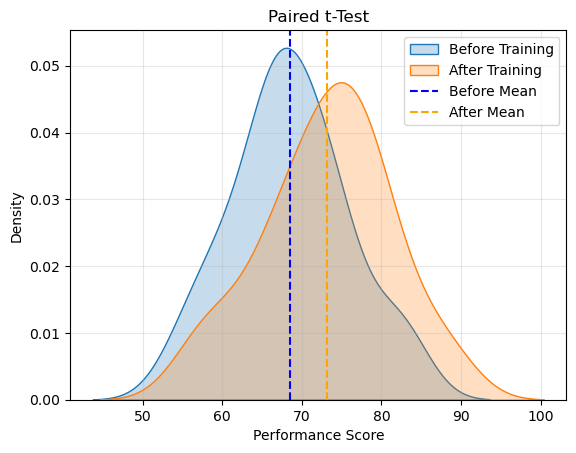

In [28]:

sns.kdeplot( Training["Before_Training"], fill=True,label="Before Training" )

sns.kdeplot( Training["After_Training"],
                fill=True,
                label="After Training"    )

plt.axvline(Training["Before_Training"].mean(), color="blue", linestyle="--", label="Before Mean" )


plt.axvline( Training["After_Training"].mean(), color="orange", linestyle="--", label="After Mean")

plt.title("Paired t-Test")

plt.xlabel("Performance Score")

plt.ylabel("Density")

plt.legend()

plt.grid(alpha=0.3)

plt.show()